In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('taxi_trip_pricing.csv')

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [ ]:
df.tail()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090
999,22.85,Morning,Weekend,3.0,Medium,Clear,4.34,NaN,0.23,29.69,45.4437


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [ ]:
df.isna().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Trip_Price']=df['Trip_Price'].fillna(df['Trip_Price'].median())


In [ ]:
col =['Trip_Distance_km','Trip_Duration_Minutes','Per_Minute_Rate','Per_Km_Rate','Base_Fare','Weather','Traffic_Conditions','Passenger_Count','Day_of_Week','Time_of_Day']

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [ ]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
weather_mode = df['Weather'].mode()[0]
df['Weather'] = df['Weather'].replace(0, weather_mode)

In [ ]:
df.isna().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [ ]:
df.shape

(1000, 11)

In [ ]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.008520,2.453000,3.503840,1.232650,0.292770,62.105210,56.541560
std,19.402661,1.079331,0.848115,0.418932,0.112664,31.339464,39.492129
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,13.107500,2.000000,2.770000,0.870000,0.197500,37.107500,34.578850
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,37.782500,3.000000,4.202500,1.580000,0.382500,87.775000,67.476650
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [ ]:
df['Trip_Price'].unique()

array([ 36.2624    ,  50.0745    ,  52.9032    ,  36.4698    ,
        15.618     ,  60.2028    ,  11.2645    , 101.1216    ,
        75.5657    ,  14.892     ,  88.1328    ,  36.118     ,
        28.9914    ,  27.4415    ,  56.716     ,  69.0049    ,
        69.6268    ,  27.3543    ,  44.7782    ,  26.2988    ,
       201.86950919,  39.2366    ,  33.632     ,  83.6965    ,
        28.2443    , 280.87730155,  64.7971    ,  24.2608    ,
        58.8121    ,  20.7765    ,  57.28      ,  61.5552    ,
        54.1018    ,  35.0164    ,  40.9225    ,  60.0471    ,
        62.7785    ,  20.791     ,  57.0482    ,  42.9921    ,
        85.884     ,  29.4758    ,  30.9982    ,  64.0553    ,
        44.844     ,  44.1197    ,  20.1596    , 104.1764    ,
        57.0766    ,  98.3796    ,  41.9343    ,  72.2695    ,
        99.8989    ,  10.2366    ,  32.342     ,  37.1504    ,
        78.715     ,  29.8609    ,  59.181     ,  47.3148    ,
        69.6575    , 320.95866358,  61.4595    ,  68.37

<Axes: >

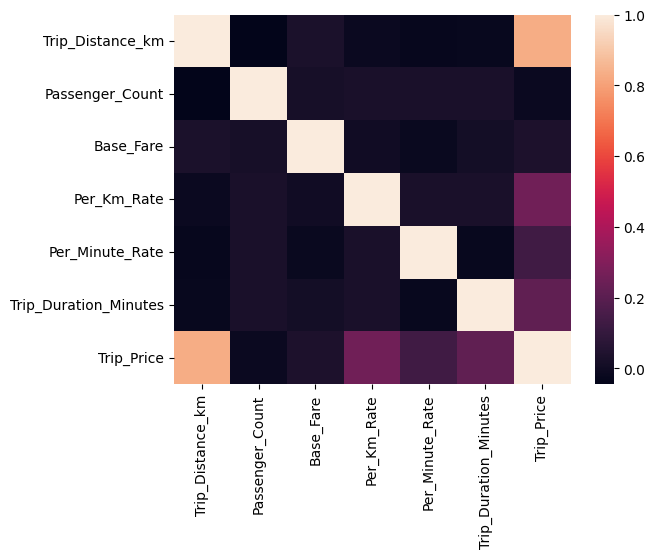

In [ ]:
sns.heatmap(df.corr(numeric_only=True))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


<Axes: xlabel='Trip_Distance_km', ylabel='Count'>

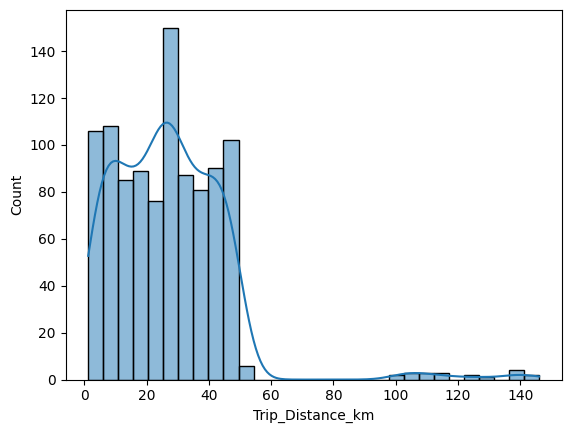

In [ ]:
sns.histplot(df['Trip_Distance_km'],kde=True)

<Axes: xlabel='Trip_Price', ylabel='Count'>

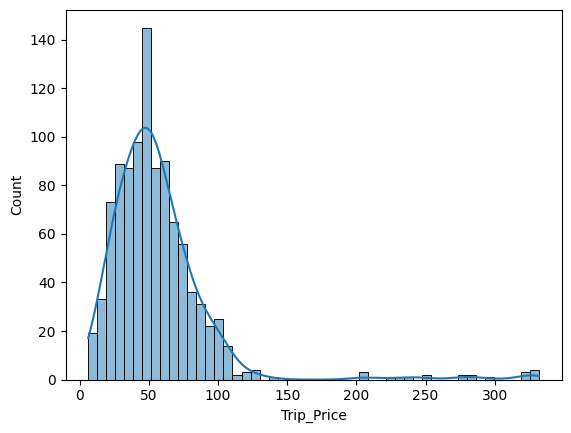

In [ ]:
sns.histplot(df['Trip_Price'],kde=True)

(array([301., 485., 170.,  23.,   1.,   0.,   5.,   3.,   5.,   7.]),
 array([  6.1269    ,  38.71857887,  71.31025774, 103.9019366 ,
        136.49361547, 169.08529434, 201.67697321, 234.26865207,
        266.86033094, 299.45200981, 332.04368868]),
 <BarContainer object of 10 artists>)

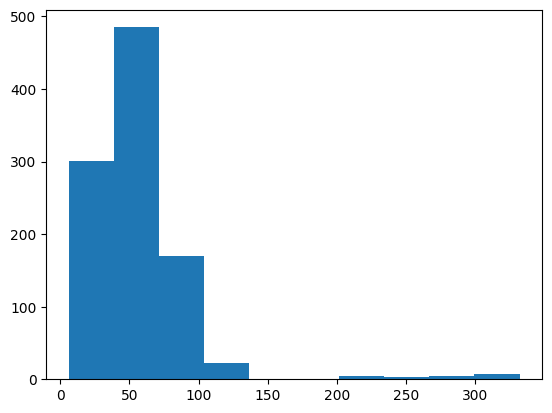

In [ ]:
plt.hist(df['Trip_Price'])

<Axes: xlabel='Passenger_Count', ylabel='Count'>

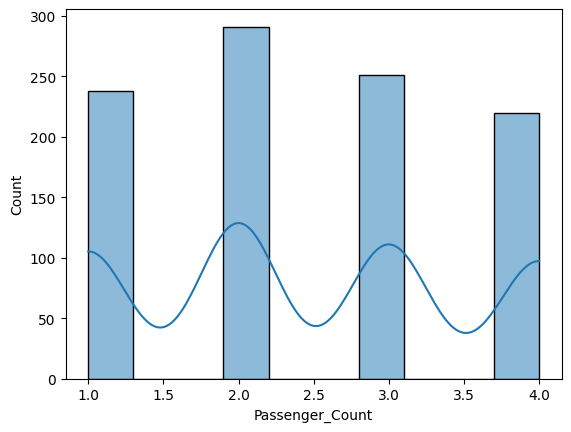

In [ ]:
sns.histplot(df['Passenger_Count'],bins=10,kde=True)

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

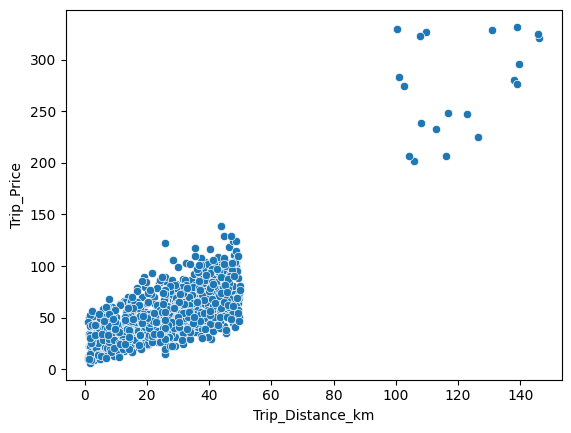

In [ ]:
sns.scatterplot(x='Trip_Distance_km',y='Trip_Price',data=df)

<Axes: xlabel='Weather', ylabel='count'>

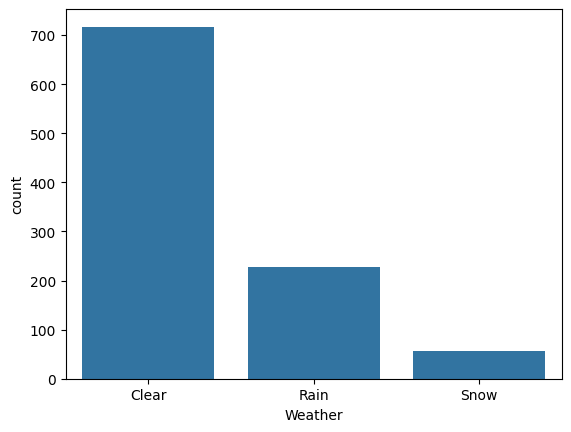

In [ ]:
sns.countplot(x='Weather',data=df)

In [ ]:
# df.info()

In [ ]:
cols=['Time_of_Day','Day_of_Week','Traffic_Conditions',' Weather']

In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Trip_Distance_km           1000 non-null   float64
 1   Passenger_Count            1000 non-null   float64
 2   Base_Fare                  1000 non-null   float64
 3   Per_Km_Rate                1000 non-null   float64
 4   Per_Minute_Rate            1000 non-null   float64
 5   Trip_Duration_Minutes      1000 non-null   float64
 6   Trip_Price                 1000 non-null   float64
 7   Time_of_Day_Evening        1000 non-null   int64  
 8   Time_of_Day_Morning        1000 non-null   int64  
 9   Time_of_Day_Night          1000 non-null   int64  
 10  Day_of_Week_Weekend        1000 non-null   int64  
 11  Traffic_Conditions_Low     1000 non-null   int64  
 12  Traffic_Conditions_Medium  1000 non-null   int64  
 13  Weather_Rain               1000 non-null   int64 

In [ ]:
# df.head()

In [ ]:
X=df.drop('Trip_Price',axis=1)
y=df['Trip_Price']

In [ ]:
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error ,mean_absolute_error,r2_score
def evaluate(model,X_train,y_train,X_test,y_test):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  print(f"Accuracy for your {model} is: ")
  print(f"R2 score for training {model} is {r2_score(y_train,train_pred)}")
  print(f"R2 score for testing {model} is {r2_score(y_test,test_pred)}")
  #MAE
  print(f"training MAE for {model} is {mean_absolute_error(y_train,train_pred)}")
  print(f"testing MAE for {model} is {mean_absolute_error(y_test,test_pred)}")
  #RMSE
  print(f"training RMSE for {model} is {root_mean_squared_error(y_train,train_pred)}")
  print(f"testing RMSE for {model} is {root_mean_squared_error(y_test,test_pred)}")


In [ ]:
from sklearn.linear_model import LinearRegression
lg=LinearRegression()
lg.fit(X_train,y_train)

LinearRegression()

In [ ]:
evaluate(lg,X_train,y_train,X_test,y_test)

Accuracy for your LinearRegression() is: 
R2 score for training LinearRegression() is 0.8530172513919803
R2 score for testing LinearRegression() is 0.7940999369917358
training MAE for LinearRegression() is 10.15891489977211
testing MAE for LinearRegression() is 10.559121890981588
training RMSE for LinearRegression() is 15.399625278644123
testing RMSE for LinearRegression() is 17.24877873579151


In [ ]:
# y_pred=lg.predict(X_test)

In [ ]:
# y_pred

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge_param = {
    'alpha':[150,200]
}

In [ ]:
ridge_search = GridSearchCV(ridge,ridge_param,cv = 5)

In [ ]:
ridge_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(), param_grid={'alpha': [150, 200]})

In [ ]:
best_ridge = ridge_search.best_estimator_

In [ ]:
evaluate(best_ridge,X_train,y_train,X_test,y_test)

Accuracy for your Ridge(alpha=150) is: 
R2 score for training Ridge(alpha=150) is 0.8124665646423596
R2 score for testing Ridge(alpha=150) is 0.7534409128948216
training MAE for Ridge(alpha=150) is 12.436736868709803
testing MAE for Ridge(alpha=150) is 12.928944153372521
training RMSE for Ridge(alpha=150) is 17.394675271993695
testing RMSE for Ridge(alpha=150) is 18.875158973592317


In [ ]:
# y_pred=lg.predict(X_test)
# y_pred

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)


DecisionTreeRegressor()

In [ ]:
dt_param={
    'max_depth':[5,7,10],
    'min_samples_split':[5,7,10],
    'min_samples_leaf':[3,5,7,9]
}

In [ ]:
tree_search =GridSearchCV(dt,dt_param,cv=5)

In [ ]:
tree_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [5, 7, 10],
                         'min_samples_leaf': [3, 5, 7, 9],
                         'min_samples_split': [5, 7, 10]})

In [ ]:
best_tree = tree_search.best_estimator_

In [ ]:
evaluate(best_tree,X_train,y_train,X_test,y_test)

Accuracy for your DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is: 
R2 score for training DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 0.9556200570849576
R2 score for testing DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 0.883174639865675
training MAE for DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 5.533501163451431
testing MAE for DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 8.887938343934792
training RMSE for DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 8.461947773895593
testing RMSE for DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=5) is 12.992678008259979


In [ ]:
pd.DataFrame({
    'feature':X.columns,
    'importance':best_tree.feature_importances_
}).sort_values('importance',ascending = False)

,feature,importance
0,Trip_Distance_km,0.845611
3,Per_Km_Rate,0.075575
5,Trip_Duration_Minutes,0.043634
4,Per_Minute_Rate,0.030866
2,Base_Fare,0.001053
1,Passenger_Count,0.000927
9,Day_of_Week_Weekend,0.000661
10,Traffic_Conditions_Low,0.000575
7,Time_of_Day_Morning,0.000381
12,Weather_Rain,0.000370


In [ ]:
# y_pred=lg.predict(X_test)
# y_pred

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
rf_param = {
    'n_estimators':[50,100,150],
    'max_depth':[3,5,7,10,15],
    'max_features':['sqrt','log2']
}

In [ ]:
rfr_serach = GridSearchCV(rfr,rf_param,cv=5)

In [ ]:
rfr_serach.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [3, 5, 7, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 150]})

In [ ]:
rfr_best= rfr_serach.best_estimator_

In [ ]:
evaluate(rfr_best,X_train,y_train,X_test,y_test)

Accuracy for your RandomForestRegressor(max_depth=15, max_features='sqrt') is: 
R2 score for training RandomForestRegressor(max_depth=15, max_features='sqrt') is 0.9674259973669779
R2 score for testing RandomForestRegressor(max_depth=15, max_features='sqrt') is 0.7807214129142089
training MAE for RandomForestRegressor(max_depth=15, max_features='sqrt') is 4.513895059709646
testing MAE for RandomForestRegressor(max_depth=15, max_features='sqrt') is 11.109572995642814
training RMSE for RandomForestRegressor(max_depth=15, max_features='sqrt') is 7.249574788740403
testing RMSE for RandomForestRegressor(max_depth=15, max_features='sqrt') is 17.800336957163427


In [ ]:
# y_pred=lg.predict(X_test)
# y_pred

In [ ]:
import pickle as pk

In [ ]:
with open("model.pkl","wb") as fs:
  pk.dump(best_ridge,fs)